In [2]:
from __future__ import annotations

import json
import os
import time
from pathlib import Path
from typing import Any, Dict, Optional, Union

import numpy as np
import torch
from scipy.spatial.distance import pdist

from falkon import LogisticFalkon
from falkon.kernels import GaussianKernel
from falkon.gsc_losses import WeightedCrossEntropyLoss
from falkon.options import FalkonOptions

import matplotlib.pyplot as plt



ConfigLike = Dict[str, Any]
ConfigInput = Union[ConfigLike, str, Path]


class LogFalkonNPLM:
    """
    NPLM test via LogisticFalkon classifier.

    Input API:
      - X: (N, d) pooled sample
      - y: (N,) or (N,1) labels in {0, 1}
           0 = reference (count N_R)
           1 = data      (count N_D)

    Notation:
      - N_R : number of reference points (y == 0)
      - N_D : number of data points      (y == 1)
      - NR  : expected data size under H0 (from config)
      - weight = NR / N_R

    Statistic:
      t = 2 * ( weight * sum_{y=0}(1 - exp(s_i)) + sum_{y=1}(s_i) )
    where s_i are LogisticFalkon outputs (scores/logits).
    """

    DEFAULT_CONFIG: ConfigLike = {
        # Kernel / Nyström
        "sigma": None,          # REQUIRED (float) for compute_statistic
        "M": "sqrt",            # int or "sqrt"

        # Regularization / solver
        "lambda": [1e-6],
        "iter": [1_000_000],
        "cg_tol": 1e-7,
        "keops": "no",

        # Optional consistency checks (if provided)
        "N_R": None,
        "N_D": None,

        # NPLM size under H0
        "NR": None,             # REQUIRED

        # Execution
        "seed": None,
        "cpu": False,
        "verbose": 1,           # 0=silent, 1=info
    }

    def __init__(self, config: Optional[ConfigInput] = None, output_path: Optional[Union[str, Path]] = None):
        self.output_path = str(output_path) if output_path is not None else None
        if self.output_path is not None:
            os.makedirs(self.output_path, exist_ok=True)

        cfg_dict = self._load_config(config) if config is not None else {}
        self.config = self._resolve_config(cfg_dict)

        self.model: Optional[LogisticFalkon] = None

        # resolved per run
        self.N_R: Optional[int] = None
        self.N_D: Optional[int] = None
        self.NR: Optional[float] = None
        self.weight: Optional[float] = None

        self._log("\n[NPLM] Initialized with config:")
        if self.config.get("verbose", 0) > 0:
            for k, v in self.config.items():
                print(f"  {k}: {v}")

    # ---------------- logging ----------------

    def _log(self, msg: str) -> None:
        if int(self.config.get("verbose", 0)) > 0:
            print(msg)

    # ---------------- config ----------------

    @staticmethod
    def _load_config(config: ConfigInput) -> ConfigLike:
        if isinstance(config, dict):
            return dict(config)

        path = Path(config)
        if not path.exists():
            raise FileNotFoundError(f"Config file not found: {path}")

        text = path.read_text(encoding="utf-8")
        suffix = path.suffix.lower()

        if suffix == ".json":
            return json.loads(text)
        if suffix in (".yml", ".yaml"):
            try:
                import yaml
            except ImportError as e:
                raise ImportError("YAML config requires `pip install pyyaml`.") from e
            return yaml.safe_load(text)

        raise ValueError("Config must be dict, .json, .yml or .yaml")

    @classmethod
    def _resolve_config(cls, user_cfg: ConfigLike) -> ConfigLike:
        cfg = dict(cls.DEFAULT_CONFIG)
        cfg.update(user_cfg)

        if isinstance(cfg["keops"], bool):
            cfg["keops"] = "yes" if cfg["keops"] else "no"

        if not isinstance(cfg["lambda"], (list, tuple)):
            cfg["lambda"] = [cfg["lambda"]]
        if not isinstance(cfg["iter"], (list, tuple)):
            cfg["iter"] = [cfg["iter"]]

        cfg["verbose"] = int(cfg.get("verbose", 0))

        # Require NR always
        if cfg.get("NR", None) is None:
            raise ValueError("Config must specify NR (expected data size under H0).")

        # sigma is required for compute_statistic; validated there (allows init without sigma if you only use estimator)
        if cfg.get("sigma", None) is not None:
            sigma = float(cfg["sigma"])
            if not np.isfinite(sigma) or sigma <= 0:
                raise ValueError(f"Config sigma must be positive finite; got sigma={sigma}")

        return cfg

    # ---------------- utility: sigma estimation ----------------

    @staticmethod
    def estimate_sigma_median(X: np.ndarray, max_points: int = 5000, seed: Optional[int] = None) -> float:
        """
        Estimate Gaussian bandwidth sigma using the median heuristic:
            sigma = median_{i<j} ||x_i - x_j||_2

        Intended use: call once on a representative sample, then store in config["sigma"].
        """
        X = np.asarray(X)
        if X.ndim != 2:
            raise ValueError("X must be 2D array (N, d)")
        X = np.ascontiguousarray(X)

        n = X.shape[0]
        if n < 2:
            raise ValueError("Need at least 2 points to estimate sigma")

        max_points = int(max_points)
        if max_points < 2:
            raise ValueError("max_points must be >= 2")

        if n > max_points:
            rng = np.random.default_rng(None if seed is None else int(seed))
            idx = rng.choice(n, size=max_points, replace=False)
            X = X[idx]

        d = pdist(X)  # Euclidean distances
        sigma = float(np.median(d))
        if not np.isfinite(sigma) or sigma <= 0:
            raise ValueError(f"Median heuristic returned invalid sigma={sigma}. Consider standardizing inputs.")
        return sigma

    # ---------------- helpers ----------------

    @staticmethod
    def _sqrt_rule(n: int) -> int:
        return int(np.sqrt(n))

    def _set_seed(self) -> None:
        seed = self.config.get("seed", None)
        if seed is None:
            self._log("[NPLM] No seed specified (non-reproducible run)")
            return
        seed = int(seed)
        self._log(f"[NPLM] Setting global seed = {seed}")
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    @staticmethod
    def _normalize_labels_01(y: np.ndarray) -> np.ndarray:
        """
        Ensure y is 1D array with values in {0,1}.
        """
        y = np.asarray(y)
        if y.ndim == 2 and y.shape[1] == 1:
            y = y.reshape(-1)
        if y.ndim != 1:
            raise ValueError("y must be shape (N,) or (N,1)")
        vals = np.unique(y)
        if not np.all(np.isin(vals, [0, 1])):
            raise ValueError(f"y must contain only 0 and 1; got unique values {vals}")
        # Keep float64 for Falkon cross-entropy
        return y.astype(np.float64, copy=False)

    def _resolve_sizes_from_labels(self, y01: np.ndarray) -> None:
        N_R = int(np.sum(y01 == 0))
        N_D = int(np.sum(y01 == 1))

        if N_R <= 0 or N_D <= 0:
            raise ValueError(f"Need both classes present: got N_R={N_R}, N_D={N_D}")

        if self.config["N_R"] is not None and int(self.config["N_R"]) != N_R:
            raise ValueError(f"Config N_R={self.config['N_R']} but labels imply N_R={N_R}")
        if self.config["N_D"] is not None and int(self.config["N_D"]) != N_D:
            raise ValueError(f"Config N_D={self.config['N_D']} but labels imply N_D={N_D}")

        self.N_R = N_R
        self.N_D = N_D
        self.NR = float(self.config["NR"])
        self.weight = self.NR / float(self.N_R)

        self._log(f"[NPLM] Label counts: N_R={self.N_R} (y=0), N_D={self.N_D} (y=1)")
        self._log(f"[NPLM] weight = NR/N_R = {self.NR}/{self.N_R} = {self.weight:.6g}")

    # ---------------- model ----------------

    def build_model(self) -> None:
        if self.N_R is None or self.N_D is None or self.weight is None:
            raise RuntimeError("Internal state not initialized. Call compute_statistic() first.")

        sigma = self.config.get("sigma", None)
        if sigma is None:
            raise ValueError(
                "Config must specify sigma (float) to train the model. "
                "You can estimate it once with `estimate_sigma_median` and then set config['sigma']."
            )
        sigma = float(sigma)

        kernel = GaussianKernel(sigma)

        M_cfg = self.config["M"]
        if isinstance(M_cfg, str):
            if M_cfg != "sqrt":
                raise ValueError("config['M'] must be an int or the string 'sqrt'")
            M = self._sqrt_rule(self.N_R + self.N_D)
        else:
            M = int(M_cfg)

        self._log(f"[NPLM] Using fixed sigma = {sigma:.6g}")
        self._log(f"[NPLM] Nyström centers M = {M}")

        opts = FalkonOptions(
            cg_tolerance=float(self.config["cg_tol"]),
            keops_active=str(self.config["keops"]),
            use_cpu=bool(self.config["cpu"]),
            debug=False,
        )

        self.model = LogisticFalkon(
            kernel=kernel,
            penalty_list=self.config["lambda"],
            iter_list=self.config["iter"],
            M=M,
            options=opts,
            loss=WeightedCrossEntropyLoss(kernel, neg_weight=float(self.weight)),
            seed=self.config.get("seed", None),
        )

    # ---------------- statistic ----------------

    @staticmethod
    def _compute_t(scores: torch.Tensor, y01: np.ndarray, weight: float) -> float:
        """
        scores: (N, 1) or (N,) torch tensor
        y01: (N,) numpy float/int with values {0,1}
        """
        if scores.ndim == 2 and scores.shape[1] == 1:
            scores = scores.reshape(-1)

        mask_ref = (y01 == 0)
        mask_data = (y01 == 1)

        mask_ref_t = torch.from_numpy(mask_ref)
        mask_data_t = torch.from_numpy(mask_data)

        s_ref = scores[mask_ref_t]
        s_data = scores[mask_data_t]

        diff = float(weight) * torch.sum(1.0 - torch.exp(s_ref))
        t = 2.0 * (diff + torch.sum(s_data))
        return float(t.item())

    def compute_statistic(self, X: np.ndarray, y: np.ndarray, return_details: bool = False):
        """
        Compute NPLM statistic from pooled X and 0/1 labels y.

        X: (N, d)
        y: (N,) or (N,1), values in {0,1}
        """
        X = np.asarray(X)
        if X.ndim != 2:
            raise ValueError("X must be 2D array (N, d)")
        X = np.ascontiguousarray(X)

        y01 = self._normalize_labels_01(y)
        if y01.shape[0] != X.shape[0]:
            raise ValueError("X and y must have the same number of rows")

        self._log("\n[NPLM] Starting computation of test statistic")
        self._set_seed()
        self._resolve_sizes_from_labels(y01)

        X_t = torch.from_numpy(X)  # zero-copy CPU view, torch.float32 if X is float32
        y_t = torch.from_numpy(y01.reshape(-1, 1)).to(dtype=X_t.dtype)

        self.build_model()

        self._log("[NPLM] Training LogisticFalkon...")
        t0 = time.time()
        self.model.fit(X_t, y_t)
        train_time = time.time() - t0
        self._log(f"[NPLM] Training finished in {train_time:.2f} s")

        scores = self.model.predict(X_t)
        t = self._compute_t(scores, y01, float(self.weight))

        self._log(f"[NPLM] Test statistic t = {t:.6g}")

        if not return_details:
            return t

        scores_flat = scores.reshape(-1)
        mask_ref_t = torch.from_numpy(y01 == 0)
        s_ref = scores_flat[mask_ref_t]
        Nw = float((float(self.weight) * torch.sum(torch.exp(s_ref))).item())

        return t, {
            "Nw": Nw,
            "train_time": float(train_time),
            "weight": float(self.weight),
            "sigma": float(self.config["sigma"]),
            "seed": self.config.get("seed", None),
            "scores": scores.detach().cpu().numpy(),
            "resolved_config": dict(self.config),
            "N_R": int(self.N_R),
            "N_D": int(self.N_D),
        }


In [3]:
def sample_ref_exp(N, rate=8.0, xmax=1.0, rng=None):
    # truncated at 1
    rng = np.random.default_rng() if rng is None else rng
    Z = 1.0 - np.exp(-rate * xmax)
    u = rng.random(N)
    return -(1.0 / rate) * np.log(1.0 - u * Z)

def sample_signal_gauss(N, mu=0.8, sigma=0.02, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    return rng.normal(loc=mu, scale=sigma, size=N)

def make_data_sample_poisson(NR=2000, NS=10, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    N_B = int(rng.poisson(NR))
    N_S = int(rng.poisson(NS))

    xb = sample_ref_exp(N_B, rng=rng)
    xs = sample_signal_gauss(N_S, rng=rng)

    x = np.concatenate([xb, xs])
    rng.shuffle(x)
    return x, xb, xs, N_B, N_S



Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

NPLM statistic t = 20.500570439356807
Size of reference = 20000
Expected background NR = 2000.0
Size of data sample = 2116
Realized N_B, N_S  = 2104 12


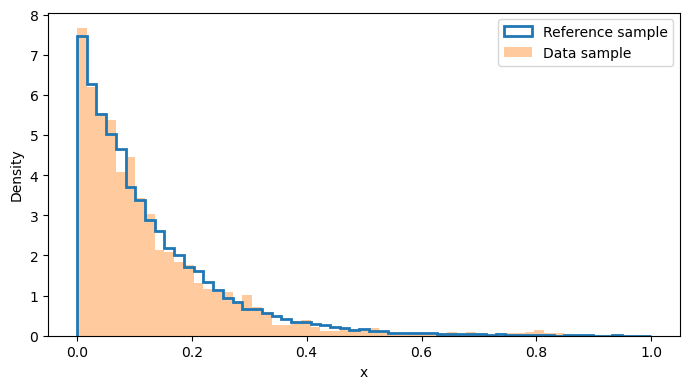

In [9]:
# --------------------------------
# Parameters
# --------------------------------

seed = 0
rng = np.random.default_rng(seed)

N_R = 20000
NR  = 2000        # expected background under H0
NS  = 10          # expected signal (for observed data)

sigma = 0.3 # from estimate_sigma_median

cfg = {
    "sigma": float(sigma),
    "NR": float(NR),
    "M": "sqrt",
    "lambda": [1e-6],
    "iter": [20000],
    "cg_tol": 1e-7,
    "keops": "no",
    "cpu": True,
    "verbose": 0,
}

# --------------------------------
# Observed statistic
# --------------------------------

x_ref = sample_ref_exp(N_R, rng=rng)
x_dat, _, _, N_B, N_S = make_data_sample_poisson(NR=NR, NS=NS, rng=rng)

X = np.concatenate([x_ref, x_dat]).reshape(-1, 1).astype(np.float64)
y = np.concatenate([
    np.zeros(len(x_ref)),
    np.ones(len(x_dat)),
]).astype(np.float64)

nplm = LogFalkonNPLM(cfg)
t_obs, details = nplm.compute_statistic(X, y, return_details=True)

print("\nNPLM statistic t =", t_obs)
print("Size of reference =", details["N_R"])
print("Expected background NR =", details["weight"] * details["N_R"])
print("Size of data sample =", details["N_D"])
print("Realized N_B, N_S  =", N_B, N_S)

# --------------------------------
# 1) Plot observed reference vs observed data
# (assumes you already ran the code and have x_ref, x_dat, t_obs, t_null)
# --------------------------------

bins_x = np.linspace(0.0, 1.0, 60)

plt.figure(figsize=(7, 4))
plt.hist(x_ref, bins=bins_x, density=True, histtype="step", linewidth=2, label="Reference sample")
plt.hist(x_dat, bins=bins_x, density=True, histtype="stepfilled", alpha=0.4, label="Data sample")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# --------------------------------
# Null toys (H0: data ~ reference)
# --------------------------------

B = 100         # number of null toys

t_null = np.empty(B)

for b in range(B):
    print(f"\n--- Null toy {b+1}/{B} ---")
    # new reference for each toy
    x_ref_b = sample_ref_exp(N_R, rng=rng)

    # null data: NS = 0
    x_dat_b, _, _, _, _ = make_data_sample_poisson(NR=NR, NS=0, rng=rng)

    X_b = np.concatenate([x_ref_b, x_dat_b]).reshape(-1, 1).astype(np.float64)
    y_b = np.concatenate([
        np.zeros(len(x_ref_b)),
        np.ones(len(x_dat_b)),
    ]).astype(np.float64)

    nplm = LogFalkonNPLM(cfg)
    t_null[b] = nplm.compute_statistic(X_b, y_b)


--- Null toy 1/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy 2/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy 3/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy 4/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy 5/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy 6/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy 7/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy 8/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy 9/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy 10/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy 11/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy 12/100 ---
Iteration 0 - penalty 1.000000e-06 - sub-iterations 20000

--- Null toy

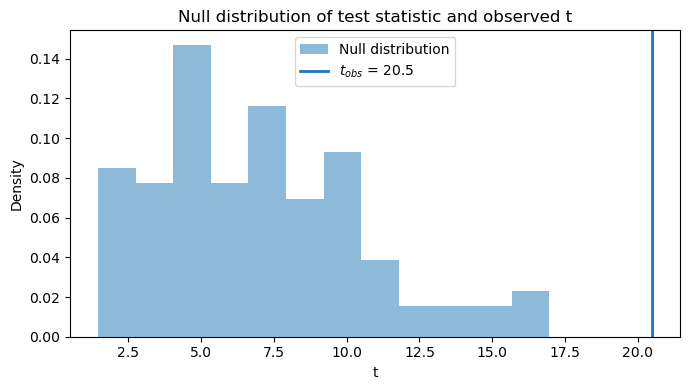

In [16]:
# --------------------------------
# 2) Plot null distribution of t and mark t_obs
# --------------------------------

plt.figure(figsize=(7, 4))
plt.hist(t_null, bins=12, density=True, alpha=0.5, label="Null distribution")
plt.axvline(t_obs, linewidth=2, label=f"$t_{{obs}}$ = {t_obs:.3g}")
plt.xlabel("t")
plt.ylabel("Density")
plt.title("Null distribution of test statistic and observed t")
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
# --------------------------------
# Monte Carlo p-value
# --------------------------------

p_value = (1.0 + np.sum(t_null >= t_obs)) / (B + 1.0)

print(f"p-value = {p_value:.4g}")


p-value = 0.009901
